In [3]:
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, END
from typing import TypedDict

# 1. 상태 정의 (데이터 전달 객체)
class ExerciseState(TypedDict):
    query: str      # 사용자 질문
    symptoms: str   # 추출된 핵심 증상
    exercises: str  # 매칭된 운동 리스트
    result: str     # 최종 리포트 결과물

# 2. LLM 초기화 (LG EXAONE 3.5 2.4B 모델 사용)
llm = Ollama(model="exaone3.5:2.4b")

# 3. 에이전트 및 프롬프트 정의

# [추출 에이전트] : 핵심 키워드 선별
extractor_prompt = PromptTemplate.from_template("""
입력된 질문에서 신체 상태나 건강 고민을 나타내는 핵심 명사만 추출하십시오.
조사나 서술어를 제외하고 쉼표로 구분된 단어만 출력하십시오.
질문: {query}
""")

def extractor_agent(state: ExerciseState):
    chain = extractor_prompt | llm
    symptoms = chain.invoke({"query": state["query"]})
    return {**state, "symptoms": symptoms.strip()}

# [후보 에이전트] : 전문 지식 기반 운동 매칭
matcher_prompt = PromptTemplate.from_template("""
제시된 증상을 개선하기 위한 최적의 운동 5가지를 선정하십시오.
각 운동별로 핵심 효과를 한 문장의 명사형으로 기술하십시오.
증상: {symptoms}
형식: 운동명 - 효과
""")

def matcher_agent(state: ExerciseState):
    chain = matcher_prompt | llm
    exercises = chain.invoke({"symptoms": state["symptoms"]})
    return {**state, "exercises": exercises.strip()}

# [답변 생성 에이전트] : 특수 기호를 배제한 개조식 리포트 생성
answer_prompt = PromptTemplate.from_template("""
당신은 건강 검진 리포트 작성 전문가입니다. 아래 정보를 바탕으로 전문적인 운동 처방 요약서를 작성하십시오.

[출력 규칙 - 엄격 준수]
1. 반드시 '명사형'으로만 종결하십시오. (예: 강화, 증진, 권장함)
2. "~합니다", "~됩니다", "~요" 같은 서술형 어미는 절대 사용 금지입니다.
3. 별표(*), 샵(#), 하이픈(-) 등 마크다운 기호를 일체 사용하지 마십시오.
4. 항목당 한 줄씩 공백으로만 구분하십시오.

[작성 예시]
분석 증상 요약
체력 저하 및 체중 증가 지속

추천 운동 처방
1 인터벌 러닝 심폐 기능 강화 및 지방 연소 효율 증대
2 스쿼트 하체 근력 보강 및 기초 대사량 상승
3 플랭크 코어 안정성 확보 및 전신 밸런스 개선

---
실제 데이터:
분석 증상: {symptoms}
추천 운동 및 효과:
{exercises}
""")
def answer_agent(state: ExerciseState):
    chain = answer_prompt | llm
    answer = chain.invoke({
        "symptoms": state["symptoms"],
        "exercises": state["exercises"]
    })
    return {**state, "result": answer.strip()}

# 4. 그래프 구조 설계
workflow = StateGraph(ExerciseState)

workflow.add_node("extractor", extractor_agent)
workflow.add_node("matcher", matcher_agent)
workflow.add_node("answer", answer_agent)

workflow.set_entry_point("extractor")
workflow.add_edge("extractor", "matcher")
workflow.add_edge("matcher", "answer")
workflow.add_edge("answer", END)

app = workflow.compile()

# 5. 실행 및 결과 출력
input_query = "체력이 안좋고 살이 계속찌는데 어떤운동을 할까"
final_result = app.invoke({"query": input_query})

print("\n" + "="*50)
print("사용자 신체 상태 분석 및 운동 처방 리포트")
print("="*50)
print(final_result["result"])


사용자 신체 상태 분석 및 운동 처방 리포트
분석 증상 요약
체력 저하 및 체중 증가 지속

추천 운동 처방
1 지구력 증진 위한 인터벌 러닝 수행 강화 권장
2 근육량 증가 및 체지방 감소를 위한 근력 강화 운동 권장
3 체지방 연소 촉진을 위한 유산소 운동 지속 수행 권장
4 유연성 향상 및 정신적 안정을 위한 요가 실천 권장
5 칼로리 소모 증진 및 하체 근력 강화를 위한 계단 오르내리기 습관 형성 권장
6 코어 안정성 강화 및 전반적인 균형 능력 향상을 위한 플랭크 수행 권장


✅ graph_structure.png 저장 완료!


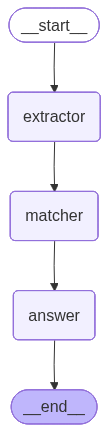

In [ ]:

from IPython.display import Image, display

# 그래프 이미지를 파일로 저장하고 출력하는 함수
def save_graph_image(app):
    try:
        # Mermaid 형식을 PNG로 변환하여 저장
        img_data = app.get_graph().draw_mermaid_png()
        with open("graph_structure.png", "wb") as f:
            f.write(img_data)
        print("graph_structure.png 저장 완료!")
        display(Image(img_data))
    except Exception as e:
        print(f"이미지 생성 실패: {e}")
        print("대신 아래 ASCII 구조를 캡처해서 사용해!")
        app.get_graph().print_ascii()

# 컴파일된 app 객체를 넣어서 실행
save_graph_image(app)